# Aprendizado de Máquina Quântico Híbrido: Classificação de Imagens Médicas

Este notebook demonstra o treinamento de um modelo híbrido (Clássico-Quântico) e a comparação com um modelo estritamente clássico.

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import sys
import os

# Adiciona o diretório raiz ao path para permitir a importação do pacote qml
sys.path.append(os.path.abspath('../../../'))

import torch
from qml.group_works.group_01.loaders.mri_loader import get_dataloaders
from qml.group_works.group_01.models.hybrid_resnet import HybridResNet18
from qml.group_works.group_01.models.classical_resnet import ClassicalResNet18
from qml.group_works.group_01.trainer.training_loop import train_model
from qml.group_works.group_01.evaluation.metrics import plot_comparison

# Configura o dispositivo para usar GPU se disponível, senão CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cuda


## 1. Carregamento dos Dados
Vamos carregar o dataset de MRI.

In [11]:
# Obtém os dataloaders para treinamento e validação
train_loader, val_loader = get_dataloaders(batch_size=8)
print(f'Treino: {len(train_loader.dataset)} amostras, Validação: {len(val_loader.dataset)} amostras')

Dataset já encontrado em ../../../data/group_works/group_01/mri_dataset. Pulando o download.
Treino: 1318 amostras, Validação: 330 amostras


## 2. Treinamento do Modelo Híbrido (Clássico-Quântico)

In [12]:
print('Inicializando Modelo Híbrido...')
# Instancia o modelo híbrido com 4 qubits
hybrid_model = HybridResNet18(num_classes=2, n_qubits=4)

# Executa o treinamento e salva o histórico
hybrid_history = train_model(
    model=hybrid_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    model_name="HybridResNet18",
    epochs=5, 
    lr=0.0004, 
    device=device
)

Inicializando Modelo Híbrido...
Época 1/5
----------


Validando: 100%|██████████| 42/42 [00:05<00:00,  7.74it/s]


Perda de Treino: 0.6709 | Acurácia: 0.5577
Perda de Valid:  0.6014 | Acurácia: 0.7667

Época 2/5
----------


Validando: 100%|██████████| 42/42 [00:02<00:00, 14.31it/s]


Perda de Treino: 0.5615 | Acurácia: 0.7822
Perda de Valid:  0.5152 | Acurácia: 0.8242

Época 3/5
----------


...

Perda de Treino: 0.5000 | Acurácia: 0.8217
Perda de Valid:  0.4864 | Acurácia: 0.8212

Época 4/5
----------


Validando: 100%|██████████| 42/42 [00:05<00:00,  7.82it/s]


Perda de Treino: 0.4492 | Acurácia: 0.8376
Perda de Valid:  0.4091 | Acurácia: 0.8727

Época 5/5
----------


Validando: 100%|██████████| 42/42 [00:05<00:00,  7.59it/s]


Perda de Treino: 0.4426 | Acurácia: 0.8225
Perda de Valid:  0.3782 | Acurácia: 0.8939

Treinamento concluído em 3m 13s


## 3. Treinamento do Modelo Clássico

In [13]:
print('Inicializando Modelo Clássico (Baseline)...')
# Instancia o modelo clássico equivalente para comparação
classical_model = ClassicalResNet18(num_classes=2)

# Executa o treinamento e salva o histórico
classical_history = train_model(
    model=classical_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    model_name="ClassicalResNet18",
    epochs=5, 
    lr=0.0004, 
    device=device
)

Inicializando Modelo Clássico (Baseline)...
Época 1/5
----------


Validando: 100%|██████████| 42/42 [00:03<00:00, 12.59it/s]


Perda de Treino: 0.6651 | Acurácia: 0.6146
Perda de Valid:  0.6069 | Acurácia: 0.7636

Época 2/5
----------


Validando: 100%|██████████| 42/42 [00:03<00:00, 12.35it/s]


Perda de Treino: 0.5996 | Acurácia: 0.7375
Perda de Valid:  0.5410 | Acurácia: 0.8030

Época 3/5
----------


...

Perda de Treino: 0.5467 | Acurácia: 0.7739
Perda de Valid:  0.4886 | Acurácia: 0.8182

Época 4/5
----------


Validando: 100%|██████████| 42/42 [00:03<00:00, 11.45it/s]


Perda de Treino: 0.5264 | Acurácia: 0.7989
Perda de Valid:  0.4697 | Acurácia: 0.7606

Época 5/5
----------


Validando: 100%|██████████| 42/42 [00:03<00:00, 12.32it/s]

Perda de Treino: 0.5067 | Acurácia: 0.8020
Perda de Valid:  0.4350 | Acurácia: 0.8364

Treinamento concluído em 1m 21s


## 4. Comparação Experimental

Gráfico comparativo salvo com sucesso em: ../../../data/group_works/group_01/comparacao_modelos.png


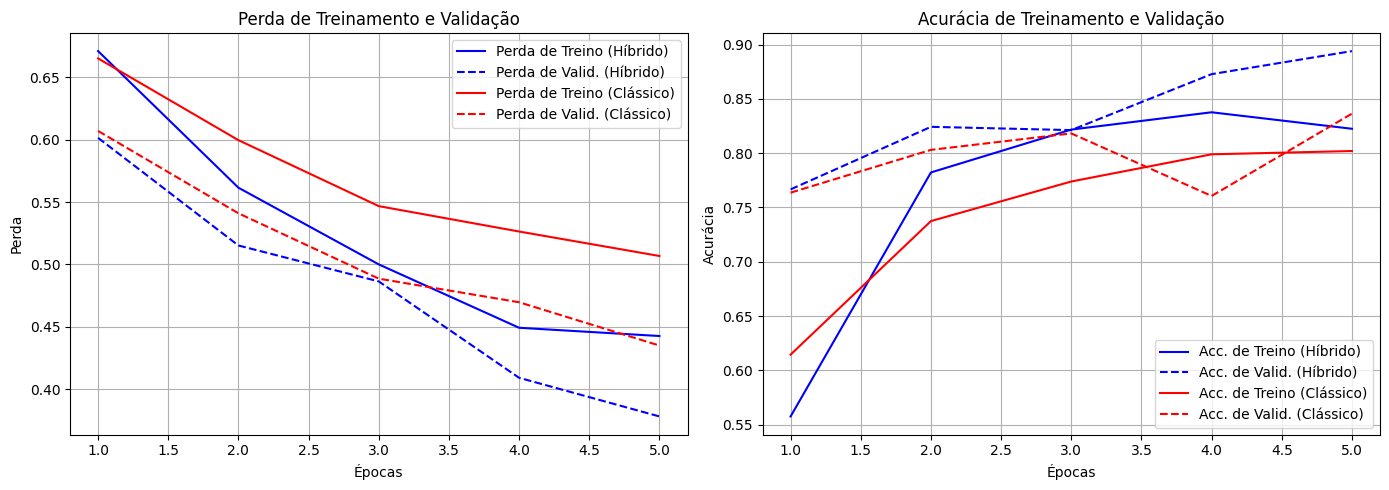

In [14]:
# Plota o gráfico de comparação e o salva na pasta de resultados
plot_comparison(hybrid_history, classical_history)